# QKD with no eavesdropper

First, a note on quantum simulators: Most quantum problems involving more than ~30 qubits cannot be simulated by most computers. No classical computer, supercomputer or GPU can simulate the full range of behavior of a 127-qubit quantum computer. Usually, the motivation for using real quantum computers is that the many entangled qubits cannot be simulated. In this case, there is no entanglement of qubits, unless we use the teleportation scheme to move information. In this case, the motivation for using real quantum computers is different: it is the no-cloning theorem. A classical computer simulating a qubit could send information about a quantum state from Alice to Bob, but if this classical information were intercepted, it could easily be duplicated, and Eve could keep a perfect copy, while sending another to Bob. This is not possible with real quantum states.

IBM Quantum recommends tackling quantum computing problems using a framework we call "Qiskit patterns". It consists of the following steps.

- Step 1: Map your problem to a quantum circuit
- Step 2: Optimize your circuit for running on real quantum hardware
- Step 3: Execute your job on IBM quantum computers using Runtime primitives
- Step 4: Post-process the results

### Qiskit patterns step 1: Map your problem to a quantum circuit

In [7]:
# Qiskit patterns step 1: Map your problem to quantum circuit
# Import some generic packages

import numpy as np
from qiskit import QuantumCircuit

# Set up a random number generator and a quantum circuit. We choose to start with 20 bits, though any number <30 should be fine.

rng = np.random.default_rng()
bit_num = 20
qc = QuantumCircuit(bit_num, bit_num)

# QKD step 1: Random bits and bases for Alice
# generate Alice's random bits

abits = np.round(rng.random(bit_num))

# generate Alice's random measurement bases. Here we will associate a "0" with the Z basis, and a "1" with the X basis.

abase = np.round(rng.random(bit_num))

# Alice's state preparation. Check that this creates states according to table 1

for n in range(bit_num):
    if abits[n] == 0:
        if abase[n] == 1:
            qc.h(n)
    if abits[n] == 1:
        if abase[n] == 0:
            qc.x(n)
        if abase[n] == 1:
            qc.x(n)
            qc.h(n)

qc.barrier()

# QKD step 2: Random bases for Bob
# generate Bob's random measurement bases.

bbase = np.round(rng.random(bit_num))

# Note that if Bob measures in Z no gates are necessary, since IBM Quantum computers measure in Z by default.
# If Bob measures in the X basis, we implement a hadamard gate qc.h to facilitate the measurement.

for m in range(bit_num):
    if bbase[m] == 1:
        qc.h(m)
    qc.measure(m, m)

Alice's bits are  [1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1.]
Alice's bases are  [0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0.]
Bob's bases are  [1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0.]


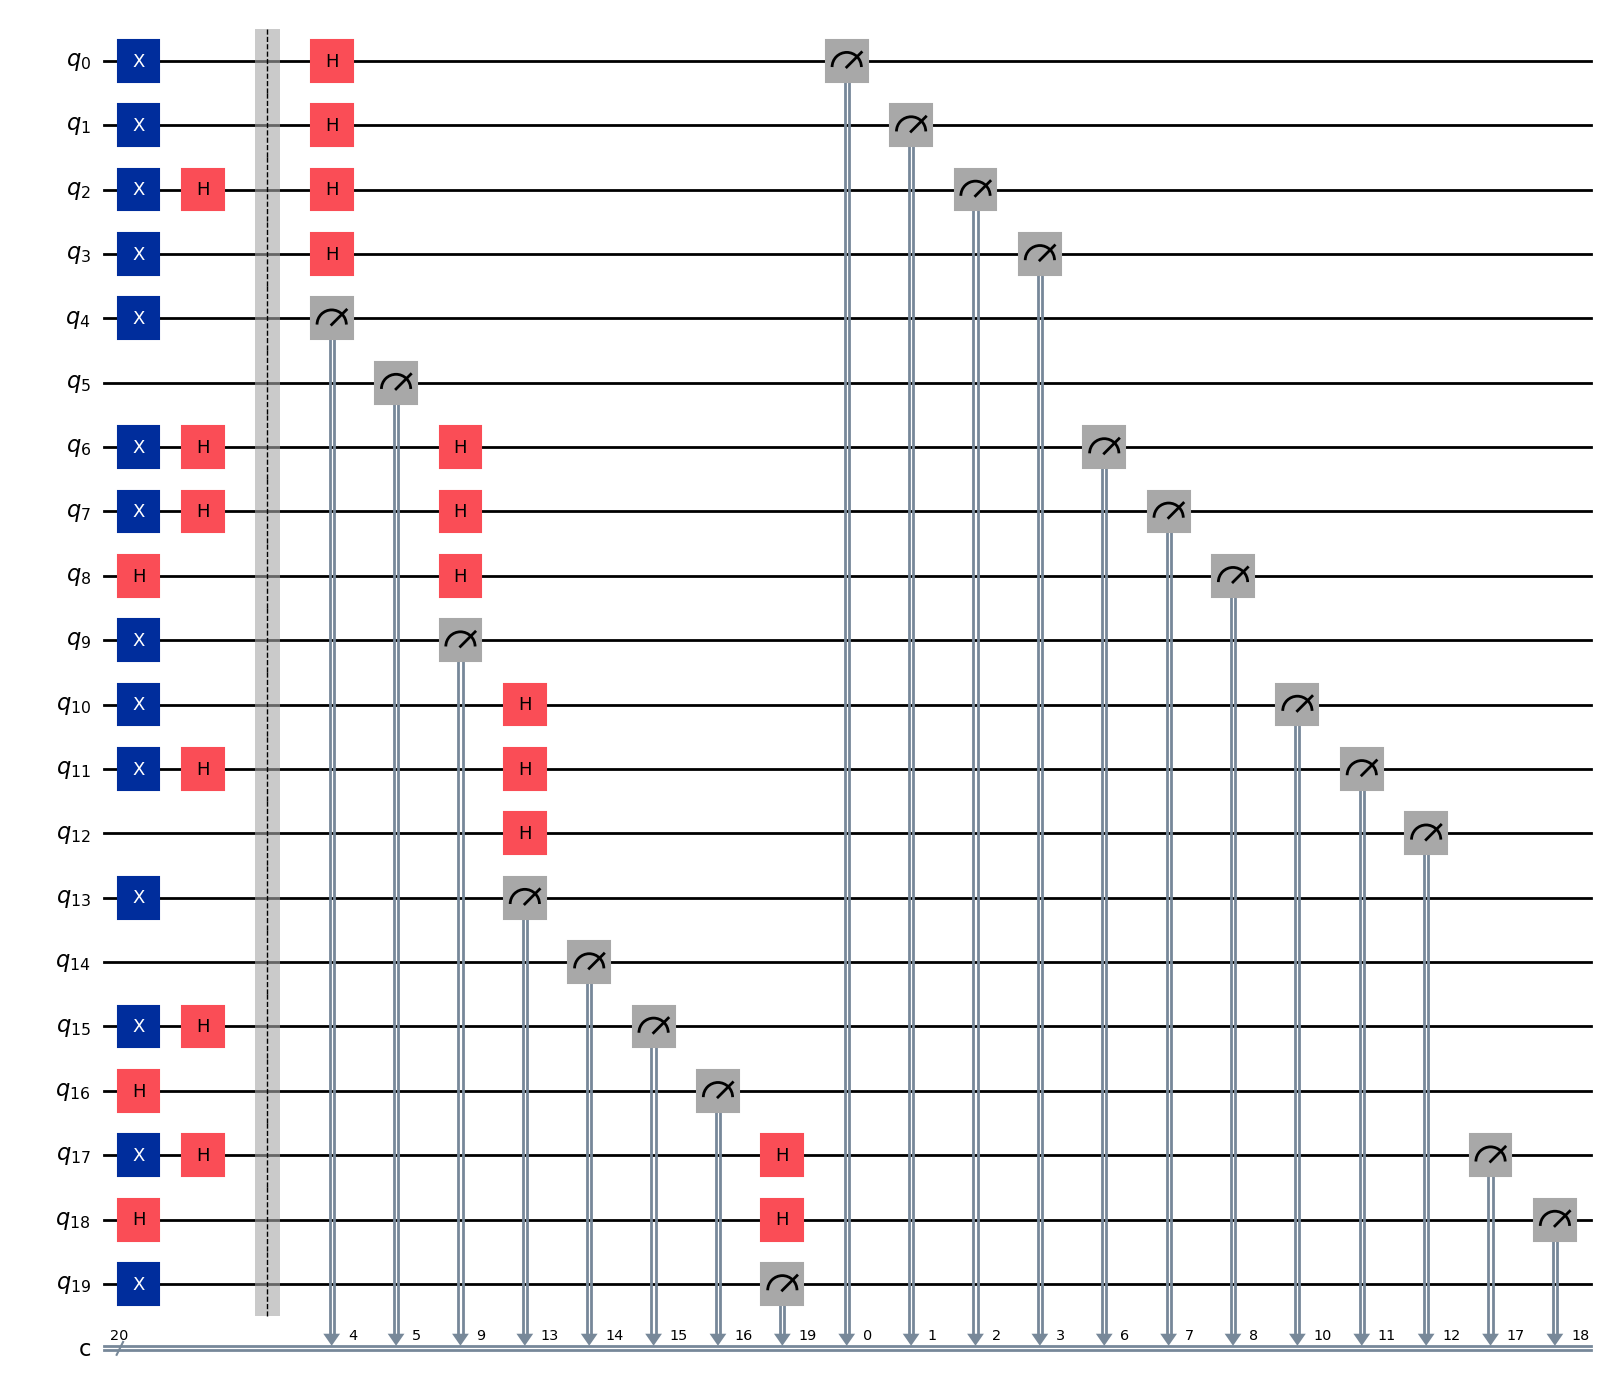

In [8]:
print("Alice's bits are ", abits)
print("Alice's bases are ", abase)
print("Bob's bases are ", bbase)
qc.draw("mpl")